In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Librerías de Procesamiento de Lenguaje Natural (NLP)
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize
import re # Para expresiones regulares (limpiar símbolos)

# Recursos lingüísticos necesarios para el español
nltk.download('punkt')           # Tokenizador
nltk.download('stopwords') 
nltk.download('punkt_tab') # Palabras comunes sin valor semántico

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\jonba\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jonba\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\jonba\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [43]:
text = os.path.join('Datos','transformados', "Donosti_booking_reviews_todas.csv")
df = pd.read_csv(text)

In [44]:
def clean_text_round(text):
    text = re.sub('\r', '', text)
    text = re.sub('\n', ' ', text)
    text = re.sub('Â', '', text)
    text = re.sub('\u200a', '', text)
    return text

In [45]:
df['full_review'] = df['positive'].fillna('') + ' ' + df['negative'].fillna('')

In [46]:
df['full_review'] = df['full_review'].apply(clean_text_round)

In [47]:
lines = " ".join(df['full_review'])

In [48]:
sentences = sent_tokenize(lines)
total_documents = len(sentences)


In [49]:
documents_tokens = []

for sentence in sentences:
    tokens = word_tokenize(sentence, language='spanish')
    documents_tokens.append(tokens)


In [50]:
all_words = []

for doc in documents_tokens:
    all_words.extend(doc)

all_words = [w.lower() for w in all_words if w.isalpha()]



In [51]:
from sklearn.feature_extraction.text import CountVectorizer

# Stopwords en español
stop_words = stopwords.words('spanish')

vectorizer = CountVectorizer(
    stop_words=stop_words,
    lowercase=True
)

X = vectorizer.fit_transform(sentences)


In [52]:
X.shape


(58, 355)

In [53]:
tdm = pd.DataFrame(
    X.toarray(),
    columns=vectorizer.get_feature_names_out()
)


In [54]:
word_freq = tdm.sum(axis=0).sort_values(ascending=False)
print(word_freq.head(10))


habitación    14
bien          13
personal      10
precio        10
ubicación      9
buena          7
limpieza       7
noche          5
lugar          5
centro         5
dtype: int64


In [55]:
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords

stop_words = stopwords.words('spanish')

tf_vectorizer = TfidfVectorizer(
    use_idf=False,      # solo TF
    norm='l1',          # normaliza por documento
    stop_words=stop_words,  # quita stopwords
    lowercase=True
)

X_tf = tf_vectorizer.fit_transform(sentences)

# Convertir a DataFrame
tf_matrix = pd.DataFrame(
    X_tf.toarray(),
    columns=tf_vectorizer.get_feature_names_out()
)

print(tf_matrix.head())


         00        05   10        13        15        20  23h   48   4a  abrió  acceso  agradable  agusto  aire  ajustan  alguien  alguno  alojamiento  alrededor  amable  amables  ambiente  amigas  amplia  amplias   andando  antiguo  aparcamiento  aparcar  aparentemente  apartamentos  aplastaba  aquel  así  atención  atentos    aunque  autobús  automática  azul  bajar  bares  barrio  bastante  baño  baños   bebidos      bien  bloqueo  bonita  bonitas      buen     buena    buenas  bueno  buenos  básicamente  cafetería  calefacción  calidad  calle  calor  cama  camareros  camarotes  camas  caminando  caminar  cansado  cargo  caro  casi  cenando    centro  cerca     check  chica  chicas  chicos  chulisimas  ciudad     coche  cocina  codigos  colchones  colchón  colina  comercial  comercios  comodidad  comodo  compartidos  compartir  compañeros  comportaron   comunes  comunicación    concha  consultas  conveniente  cortina  cortinas  creemos  cuadras  cuesta  céntrico  código    cómoda  \

In [56]:
# Convertir a binario: 1 si aparece, 0 si no
binary_matrix = (tf_matrix > 0).astype(int)

# Sumar por columna → cuántas frases contienen cada palabra
word_in_sentences = binary_matrix.sum(axis=0)
word_in_sentences_sorted = word_in_sentences.sort_values(ascending=False)
print(word_in_sentences_sorted.head(10))


bien          12
habitación    11
precio         9
ubicación      9
personal       7
buena          7
limpieza       7
noche          5
lugar          5
calidad        5
dtype: int64


In [57]:
N = tf_matrix.shape[0]

idf_vector = np.log(N / word_in_sentences)
print(idf_vector.sort_values(ascending=False).head(10))


área          4.060443
00            4.060443
05            4.060443
trabajar      4.060443
trabajan      4.060443
toca          4.060443
tiempo        4.060443
terminadas    4.060443
tarden        4.060443
tabla         4.060443
dtype: float64


In [58]:
tfidf_matrix0 = tf_matrix * idf_vector


In [59]:
print(tfidf_matrix0.iloc[3].sort_values(ascending=False).head(10))


andando     0.128903
buen        0.128903
fácil       0.106898
ruido       0.106898
centro      0.084894
servicio    0.064451
zonas       0.064451
unas        0.064451
mañana      0.064451
min         0.064451
Name: 3, dtype: float64


In [60]:
sentence_scores = tfidf_matrix0.apply(
    lambda row: row[row > 0].mean(),
    axis=1
)
print(sentence_scores.sort_values(ascending=False).head(10))


14    4.060443
39    1.683648
17    1.408995
2     1.408995
47    1.353481
25    1.353481
28    1.276465
1     1.235708
33    1.197170
5     1.174655
dtype: float64


In [61]:
average_score = sentence_scores.mean()
average_score

np.float64(0.7111712611634904)

In [62]:
def _generate_summary(sentences, sentence_scores, average_score):
    summary = ''
    sentence_count = 0
    
    for i, sentence in enumerate(sentences):
        if sentence_scores.iloc[i] >= average_score:
            summary += " " + sentence
            sentence_count += 1
            
    return summary


In [63]:
summary = _generate_summary(sentences, sentence_scores, 1.3 * average_score)
print(summary)

 En general todo bien. Un poco lejos del centro. Es un lugar ordenado y estructurado. Recomendable. El resto todo muy bien! Buena ubicación. Básicamente p gente joven. Los baños siempre limpios. El pequeño bloqueo de madera no es suficiente. Sugiero incluir cortinas pequeñas. El personal muy amable . Y la habitación familiar amplia . Las camas no son cómodas. Camarotes sin cortina y muy pequeños. Las habitaciones son amplias y los colchones cómodos.


In [64]:
# opiniones negativas
neg_reviews = df['negative'].dropna()

sentences = []
for review in neg_reviews:
    sentences.extend(sent_tokenize(review, language='spanish'))

print(f"Número de frases negativas: {len(sentences)}")


Número de frases negativas: 45


In [65]:
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

# Definir stopwords en español
stop_words_es = stopwords.words('spanish')

tfidf_vectorizer = TfidfVectorizer(
    stop_words=stop_words_es,  # <- nombre correcto
    lowercase=True,
    max_df=0.9,
    min_df=5,
    ngram_range=(1,2)
)

tfidf_matrix = tfidf_vectorizer.fit_transform(sentences)


In [66]:
from sklearn.cluster import KMeans

k = 4
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(tfidf_matrix)

labels = kmeans.labels_


c:\Users\jonba\.conda\envs\R6_Amarillo\lib\site-packages\sklearn\base.py:1389: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (4). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


In [67]:
import numpy as np

# Número de palabras a mostrar por cluster
top_n = 15

# Nombres de las palabras del TF-IDF
feature_names = tfidf_vectorizer.get_feature_names_out()

# Orden de importancia de cada palabra en cada cluster
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]  # de mayor a menor

# Mostrar las top 15 palabras por cluster
for i in range(k):  # k = número de clusters
    print(f"\nCluster {i} - Top {top_n} palabras clave:")
    top_words = [feature_names[ind] for ind in order_centroids[i, :top_n]]
    print(", ".join(top_words))




Cluster 0 - Top 15 palabras clave:
habitación

Cluster 1 - Top 15 palabras clave:
habitación

Cluster 2 - Top 15 palabras clave:
habitación

Cluster 3 - Top 15 palabras clave:
habitación


In [68]:
from nltk.corpus import stopwords
nltk.download('stopwords')  # si no lo has hecho ya

stop_words_es = stopwords.words('spanish')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jonba\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [69]:
from sklearn.feature_extraction.text import TfidfVectorizer

tf_vectorizer = TfidfVectorizer(
    stop_words=stop_words_es,  # <- lista de NLTK
    lowercase=True
)

# Usar las mismas frases que para K-Means
neg_sentences = sentences  # o la lista exacta usada para labels

X_tf = tf_vectorizer.fit_transform(neg_sentences)
tfidf_matrix0 = pd.DataFrame(X_tf.toarray(), columns=tf_vectorizer.get_feature_names_out())



In [70]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', None)

top_n_words = 15
top_n_sentences = 5
k = len(np.unique(labels))

# Diccionario para nombrar clusters según interpretación de palabras
# Puedes ajustar los nombres según lo que observes
cluster_names = {
    0: "Comodidad y equipamiento",
    1: "Ubicación y accesibilidad",
    2: "Limpieza y confort",
    3: "Comodidad + ubicación"
}

for i in range(k):
    # Frases del cluster
    cluster_sentences = [sent for sent, label in zip(sentences, labels) if label == i]
    
    # TF-IDF promedio por palabra dentro del cluster
    cluster_rows = tfidf_matrix0.iloc[[j for j, l in enumerate(labels) if l == i]]
    tfidf_mean = cluster_rows.mean(axis=0)
    
    # Top palabras
    top_words = tfidf_mean.sort_values(ascending=False).head(top_n_words).index.tolist()
    
    print(f"\nCluster {i} - {cluster_names.get(i, 'Tema desconocido')}")
    print(f"Top {top_n_words} palabras: {', '.join(top_words)}")
    
    # Ejemplos de frases
    print(f"Ejemplos de frases ({top_n_sentences}):")
    for sent in cluster_sentences[:top_n_sentences]:
        print("-", sent)



Cluster 0 - Comodidad y equipamiento
Top 15 palabras: bien, lejos, cortinas, centro, dormir, gustó, desayuno, mensaje, noche, parking, camas, horas, resto, privacidad, sucio
Ejemplos de frases (5):
- Que no te dejen entrar hasta las 15 horas y que si te dejan antes, a las 13 horas, hay que pagar 15 euros.
- Un poco lejos del centro.
- No es fácil encontrar aparcamiento si llevas coche y es zona verde (de pago, aunque la mañana de un sábado son solo 4 € mucho más económico que un parking)
- Quizás un poco lejos del centro para ir andando
- A las 05:00 han llegado un grupo haciendo ruido/ bebidos supuestamente.

Cluster 1 - Ubicación y accesibilidad
Top 15 palabras: habitación, pequeña, maletas, incómodas, justita, fotos, amplia, parece, camas, manipular, estrecha, poder, igual, alguien, check
Ejemplos de frases (5):
- La habitación de 6 era pequeña para dejar maletas, mochilas, etc. y un baño para 6 chicas puede quedarse escaso en ocasiones.
- Camas incómodas y habitación justita.
- La

## separacion


Descarga de los CSV

In [71]:
base_path = os.path.join('Datos', 'Transformados')

df_vitoria = pd.read_csv(os.path.join(base_path, 'Vitoria_booking_reviews_todas.csv'))
df_donosti = pd.read_csv(os.path.join(base_path, 'Donosti_booking_reviews_todas.csv'))
df_BilbaoMuseo = pd.read_csv(os.path.join(base_path, 'BilbaoMuseo_booking_reviews_todas.csv'))
df_BilbaolaVieja = pd.read_csv(os.path.join(base_path, 'BilbaolaVieja_booking_reviews_todas.csv'))
df_CodobaPatio = pd.read_csv(os.path.join(base_path, 'CordobaPatio_booking_reviews_todas.csv'))
df_GranadaCatedral = pd.read_csv(os.path.join(base_path, 'GranadaCatedral_booking_reviews_todas.csv'))
df_MadridPalacioReal = pd.read_csv(os.path.join(base_path, 'MadridPalacioReal_booking_reviews_todas.csv'))
df_MalagaLaMerced = pd.read_csv(os.path.join(base_path, 'MalagaLaMerced_booking_reviews_todas.csv'))
df_MalagaTeatroRomano = pd.read_csv(os.path.join(base_path, 'MalagaTeatroRomano_booking_reviews_todas.csv'))
df_PamplonaYamaguchi = pd.read_csv(os.path.join(base_path, 'PamplonaYamaguchi_booking_reviews_todas.csv'))
df_ValenciaAbastos = pd.read_csv(os.path.join(base_path, 'ValenciaAbastos_booking_reviews_todas.csv'))
df_ValenciaJardinBotanico = pd.read_csv(os.path.join(base_path, 'ValenciaJardinBotanico_booking_reviews_todas.csv'))

In [72]:
# --- Ruta base ---
base_path = os.path.join('Datos', 'Transformados')

# --- Diccionario archivo → hotel ---
files_hotels = {
    "Vitoria_booking_reviews_todas.csv": "Vitoria",
    "Donosti_booking_reviews_todas.csv": "Donosti",
    "BilbaoMuseo_booking_reviews_todas.csv": "BilbaoMuseo",
    "BilbaolaVieja_booking_reviews_todas.csv": "BilbaolaVieja",
    "CordobaPatio_booking_reviews_todas.csv": "CordobaPatio",
    "GranadaCatedral_booking_reviews_todas.csv": "GranadaCatedral",
    "MadridPalacioReal_booking_reviews_todas.csv": "MadridPalacioReal",
    "MalagaLaMerced_booking_reviews_todas.csv": "MalagaLaMerced",
    "MalagaTeatroRomano_booking_reviews_todas.csv": "MalagaTeatroRomano",
    "PamplonaYamaguchi_booking_reviews_todas.csv": "PamplonaYamaguchi",
    "ValenciaAbastos_booking_reviews_todas.csv": "ValenciaAbastos",
    "ValenciaJardinBotanico_booking_reviews_todas.csv": "ValenciaJardinBotanico"
}

all_dfs = []

# --- Leer, añadir hotel y acumular ---
for file, hotel_name in files_hotels.items():
    file_path = os.path.join(base_path, file)
    df = pd.read_csv(file_path, encoding="utf-8-sig")
    df["hotel"] = hotel_name
    all_dfs.append(df)

# --- Concatenar ---
df_all_hotels = pd.concat(all_dfs, ignore_index=True)

# --- Guardar resultado ---
df_all_hotels.to_csv(
    os.path.join(base_path, "Todos_hoteles_booking_reviews.csv"),
    index=False,
    encoding="utf-8-sig"
)

print(f"TOTAL RESEÑAS COMBINADAS: {len(df_all_hotels)}")

TOTAL RESEÑAS COMBINADAS: 2177


In [73]:
df = pd.read_csv(
    os.path.join('Datos', 'Transformados', 'Todos_hoteles_booking_reviews.csv'),
    encoding="utf-8-sig"
)

df.shape

(2177, 8)

Calculo de la media, mediana, maximo, minimo

In [74]:
def tabla_puntuaciones(diccionario_hoteles):
    """
    Recibe un diccionario con nombre del hotel y su DataFrame
    y devuelve una tabla con MEDIA, MEDIANA, MODA, MÁXIMO y MÍNIMO.
    """
    
    resultados = []

    for hotel, df in diccionario_hoteles.items():
        # Asegurar que score es numérico
        scores = pd.to_numeric(df['score'], errors='coerce').dropna()
        
        resultados.append({
            "HOTEL": hotel,
            "MEDIA": round(scores.mean(), 2),
            "MEDIANA": scores.median(),
            "MODA": scores.mode().iloc[0] if not scores.mode().empty else None,
            "MÁXIMO": scores.max(),
            "MÍNIMO": scores.min()
        })
    
    return pd.DataFrame(resultados)

In [75]:
hoteles = {
    "Líbere Vitoria": df_vitoria,
    "Koisi Hostel Donostia": df_donosti,
    "Líbere Bilbao Museo": df_BilbaoMuseo,
    "Líbere Bilbao La Vieja": df_BilbaolaVieja,
    "Líbere Córdoba Patio": df_CodobaPatio,
    "Líbere Granada Catedral": df_GranadaCatedral,
    "Líbere Madrid Palacio Real": df_MadridPalacioReal,
    "Líbere Málaga La Merced": df_MalagaLaMerced,
    "Líbere Málaga Teatro Romano": df_MalagaTeatroRomano,
    "Líbere Pamplona Yamaguchi": df_PamplonaYamaguchi,
    "Líbere Valencia Abastos": df_ValenciaAbastos,
    "Líbere Valencia Jardín Botánico": df_ValenciaJardinBotanico
}

In [76]:
tabla_scores = tabla_puntuaciones(hoteles)
tabla_scores

,HOTEL,MEDIA,MEDIANA,MODA,MÁXIMO,MÍNIMO
0,Líbere Vitoria,8.58,9.0,10.0,10.0,1.0
1,Koisi Hostel Donostia,8.22,8.0,8.0,9.0,7.0
2,Líbere Bilbao Museo,8.04,9.0,10.0,10.0,1.0
3,Líbere Bilbao La Vieja,8.08,8.0,9.0,9.0,7.0
4,Líbere Córdoba Patio,9.27,10.0,10.0,10.0,8.0
5,Líbere Granada Catedral,8.60,9.0,10.0,10.0,1.0
6,Líbere Madrid Palacio Real,8.16,9.0,9.0,10.0,1.0
7,Líbere Málaga La Merced,7.60,8.0,8.0,10.0,3.0
8,Líbere Málaga Teatro Romano,8.00,8.0,9.0,10.0,1.0
9,Líbere Pamplona Yamaguchi,8.74,9.0,10.0,10.0,1.0


## Tabla de frecuencias y wordcloud y graficos

In [77]:
negative_reviews = df['negative'].dropna()
negative_reviews = negative_reviews.apply(clean_text_round)

# Unir todo el texto negativo
negative_text = " ".join(negative_reviews)

In [78]:
# Tokenizar palabras
tokens_neg = word_tokenize(negative_text, language='spanish')

# Limpiar: minúsculas, alfabéticas, sin stopwords
stop_words_es = stopwords.words('spanish')

tokens_neg_clean = [
    w.lower() for w in tokens_neg
    if w.isalpha() and w.lower() not in stop_words_es
]

In [79]:
# Tabla de frecuencias
freq_neg = pd.Series(tokens_neg_clean).value_counts()

# Convertir a DataFrame
freq_neg_df = freq_neg.reset_index()
freq_neg_df.columns = ['Palabra', 'Frecuencia']

print("\nTop 20 palabras negativas más frecuentes:")
print(freq_neg_df.head(20))


Top 20 palabras negativas más frecuentes:
        Palabra  Frecuencia
0          cama         260
1          sofá         185
2   apartamento         113
3    habitación         109
4          bien         106
5            si         103
6          baño          88
7      incómodo          75
8          solo          73
9         noche          65
10          dos          61
11        ruido          60
12     personas          58
13     limpieza          58
14        falta          52
15     personal          50
16       cocina          50
17        check          48
18            q          47
19       dormir          47


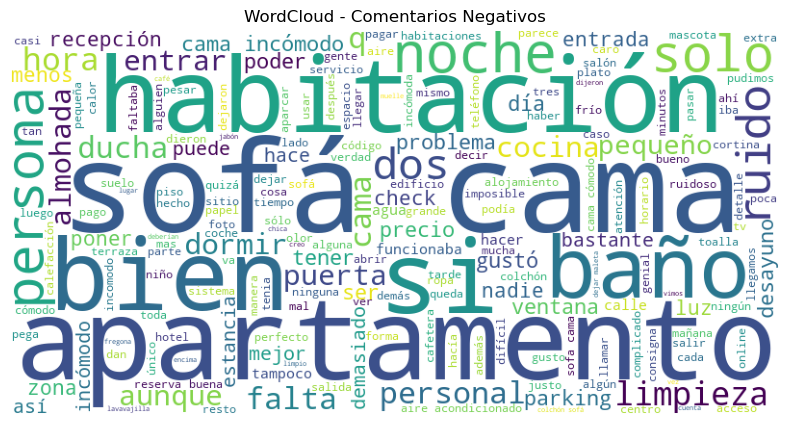

In [80]:
from wordcloud import WordCloud

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(" ".join(tokens_neg_clean))

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud)
plt.axis('off')
plt.title("WordCloud - Comentarios Negativos")
plt.show()

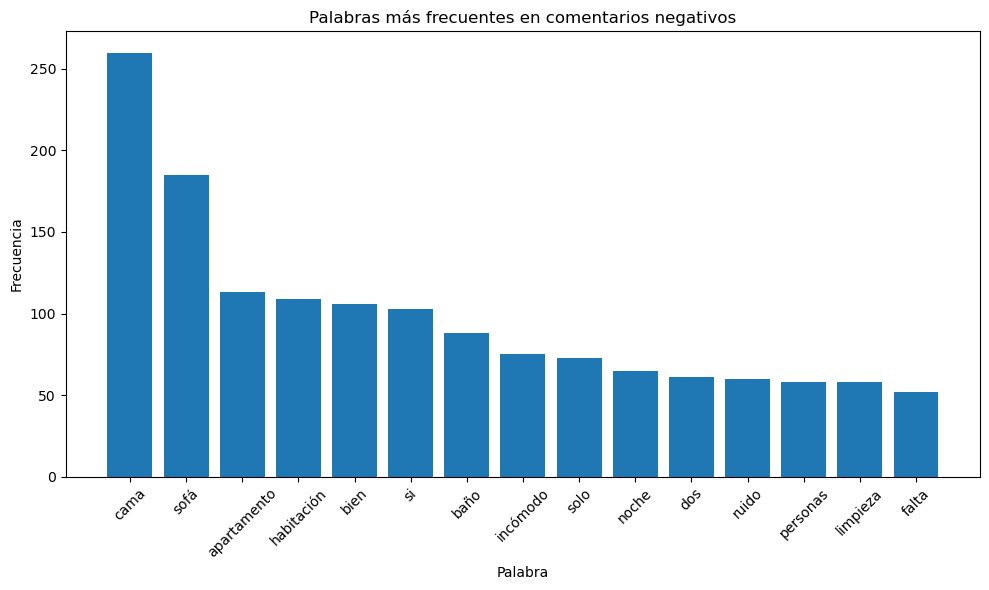

In [81]:
top_n = 15
top_words = freq_neg_df.head(top_n)

plt.figure(figsize=(10, 6))
plt.bar(top_words['Palabra'], top_words['Frecuencia'])
plt.xticks(rotation=45)
plt.title("Palabras más frecuentes en comentarios negativos")
plt.xlabel("Palabra")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()